Week6 things Dpo trainer

Because there is a hardware constraint I am using the Tiny-Llama

In [ ]:
!pip install -q transformers datasets accelerate bitsandbytes trl

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import torch
from trl import DPOTrainer,DPOConfig

In [ ]:
# #Setup the api and key for the use of the huggingface
# from google.colab import userdata
# import os

# os.environ["HF_TOKEN"] = userdata.get("HF_Token")

In [ ]:
#Loading model
model_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0"


model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    trust_remote_code=True,
    dtype=torch.bfloat16
    # token=True
)
ref_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    trust_remote_code=True,
    dtype=torch.bfloat16
    # token=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
torch.cuda.empty_cache()
# Load data and the tokenizer for the training
data = load_dataset("Anthropic/hh-rlhf")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token



In [ ]:
# 1. Configure the strict boundaries for the Colab T4
dpo_config = DPOConfig(
    output_dir="./dpo_results",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=1,
    beta=0.3,
    optim="paged_adamw_8bit",
    max_length=512
)

# 2. Initialize the trainer
trainer = DPOTrainer(
    ref_model=ref_model,
    model=model,
    args=dpo_config,
    train_dataset=data["train"].select(range(125)),
    eval_dataset=data["test"].select(range(125)),
    processing_class=tokenizer
)


trainer.train()
log_history = trainer.state.log_history

# 3. Filter out evaluation metrics or final summaries to isolate the step logs
dpo_metrics = []
for log in log_history:
    # We check for 'rewards/margins' to ensure it's a standard training step log
    if "rewards/margins" in log:
        step_data = {
            "step": log.get("step"),
            "loss": log.get("loss"),
            "margin": log.get("rewards/margins"),
            "accuracy": log.get("rewards/accuracies"),
            "reward_chosen": log.get("rewards/chosen"),
            "reward_rejected": log.get("rewards/rejected")
        }
        dpo_metrics.append(step_data)

# Example: Print the first logged step's metrics
print(dpo_metrics[0])

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,0.705792
20,0.657183
30,0.691632
40,0.680155
50,0.691646
60,0.696211
70,0.685692
80,0.670867
90,0.676294
100,0.668701


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'step': 10, 'loss': 0.7057915210723877, 'margin': -0.024407902639359234, 'accuracy': 0.4, 'reward_chosen': 0.007147922413423657, 'reward_rejected': 0.031555825041141364}


PAD:

There is a sudden jump and down in the loss it is because of the beta mis allignment currently it is at 0.3 but I think I need to increase it

In [ ]:
# 1. Translate string to tensor and send it to the GPU

inputs = tokenizer("""<|system|>
You are a helpful assistant.</s>
<|user|>
What is the meaning of life?</s>
<|assistant|>
""", return_tensors="pt").to(model.device)

# 2. Generate the output tensors (always set a max limit so it doesn't loop forever)
outputs1 = model.generate(**inputs, max_new_tokens=100)
outputs2 = ref_model.generate(**inputs, max_new_tokens=100)
# 3. Translate the first output sequence back to a string and print it
final_text1 = tokenizer.decode(outputs1[0], skip_special_tokens=True)
final_text2 = tokenizer.decode(outputs2[0], skip_special_tokens=True)
print(final_text1)
print(final_text2)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in LlamaDecoderLayer. Setting `past_key_values=None`.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|system|>
You are a helpful assistant.
<|user|>
What is the meaning of life?
<|assistant|>
The 


































































































<|system|>
You are a helpful assistant.
<|user|>
What is the meaning of life?
<|assistant|>
The meaning of life is a complex and multifaceted question that has been debated and explored by philosophers, scientists, and spiritual seekers for centuries. The meaning of life is often defined as the purpose or goal of human existence, but it can also be interpreted as a deeper sense of meaning, purpose, or significance in one's life.

Some philosophers believe that the meaning of life is found in the pursuit of knowledge, wisdom, and compass


This behaviour of generating only the empty space is because of the prompt not being given propely and also the ai are pretty much trained by giving the correct prompt but here the traning proces is not perfect or nearer so these type of behaviour is common

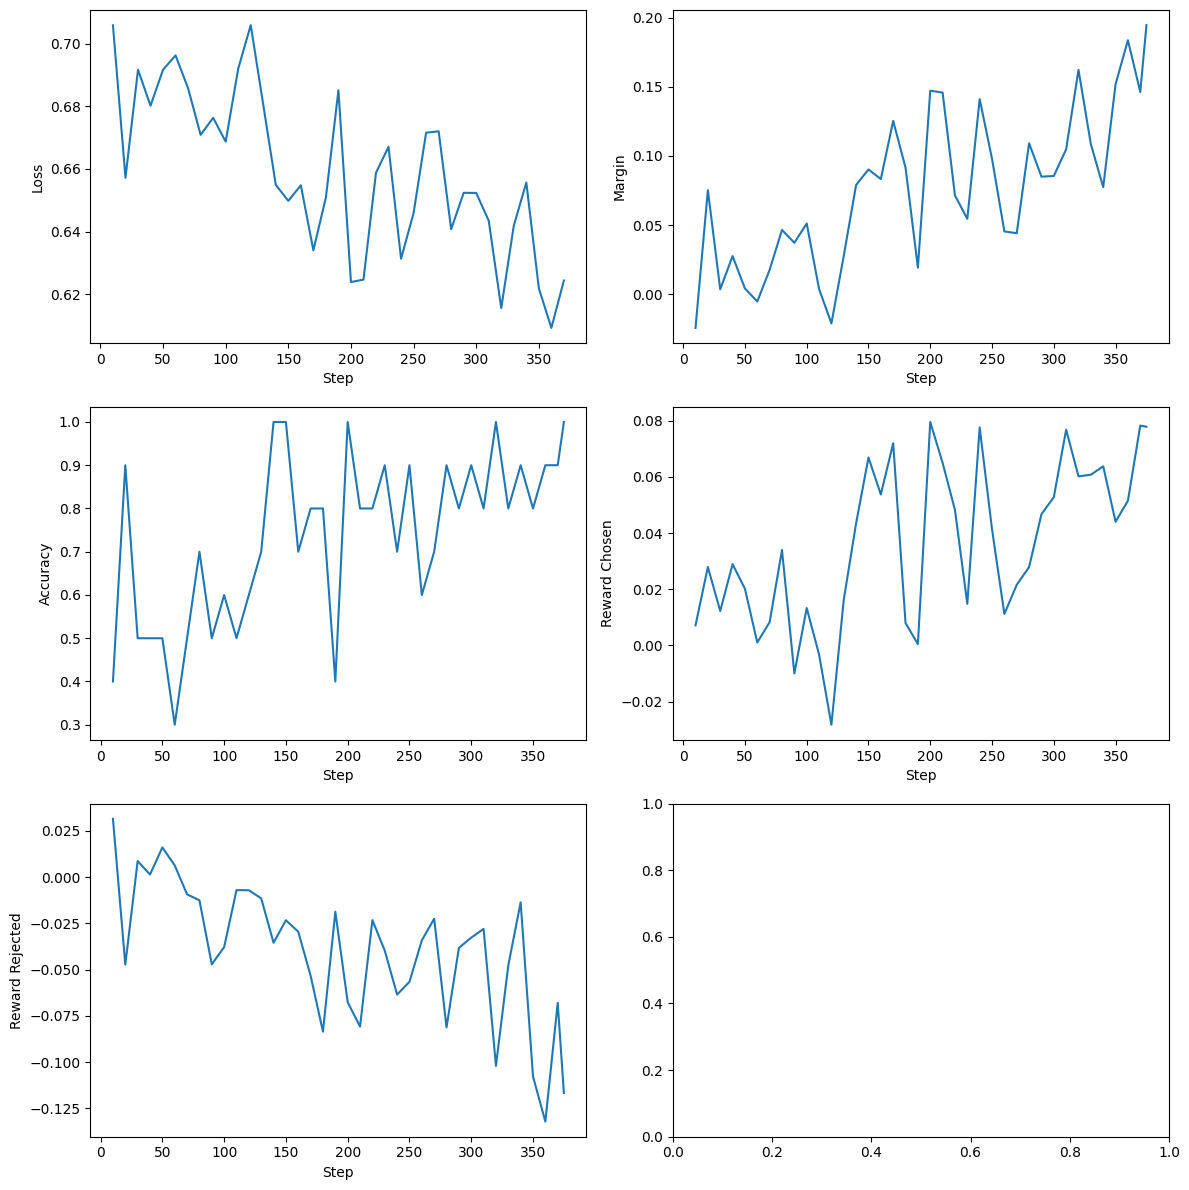

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# axes = axes.flatten()
axes[0][0].plot([d["step"] for d in dpo_metrics], [d["loss"] for d in dpo_metrics])
axes[0][0].set_xlabel("Step")
axes[0][0].set_ylabel("Loss")
axes[0][1].plot([d["step"] for d in dpo_metrics], [d["margin"] for d in dpo_metrics])
axes[0][1].set_xlabel("Step")
axes[0][1].set_ylabel("Margin")
axes[1][0].plot([d["step"] for d in dpo_metrics], [d["accuracy"] for d in dpo_metrics])
axes[1][0].set_xlabel("Step")
axes[1][0].set_ylabel("Accuracy")
axes[1][1].plot([d["step"] for d in dpo_metrics], [d["reward_chosen"] for d in dpo_metrics])
axes[1][1].set_xlabel("Step")
axes[1][1].set_ylabel("Reward Chosen")
axes[2][0].plot([d["step"] for d in dpo_metrics], [d["reward_rejected"] for d in dpo_metrics])
axes[2][0].set_xlabel("Step")
axes[2][0].set_ylabel("Reward Rejected")
plt.tight_layout()
plt.show()

As I said above the peaks and slopes are because of the wrong beta value which is needed to be changed and made the trail and error but because this is a free tyer gpu this kind of events are not possible

The geberation of the model some how got ruined due to the traning discripencies so I decided to leave it as it is because the thing is traning process takes too much time in this free hard ware and I don't want to spend dollars on the pro versions to only use it for very less hours